# 오분류 다발 키워드·IP 분석 — 무엇이 모델을 헷갈리게 하나

> v2_sweepA · test 754개 · **배포 운영점 THR=0.7049** 기준 · 노트북 Run All 자동 생성.

**소목적**: FP(낚인 실패)·FN(놓친 성공)에 *유난히 많이 얽힌* 키워드·IP를 찾는다. 상위목적(모델이 성패를 어떻게 학습했고 FN·FP가 왜 생기나)을 *구체적 콘텐츠*로 설명.

**지표(빈도가 아니라 조건부 오분류율)**:
- **과대예측률(FP)** = FP/(FP+TN) — *그 키워드를 가진 **실제 실패** 제품이 성공으로 낚인 비율*. base=143/574.
- **미포착률(FN)** = FN/(FN+TP) — *그 키워드를 가진 **실제 성공** 제품이 실패로 놓쳐진 비율*. base=43/180.
- 표본 필터: FP분석 실패표본≥5·FP≥3 / FN분석 성공표본≥5·FN≥2. (단순 빈도는 간식·달콤 같은 흔한 키워드만 떠서 사용 안 함)

In [1]:
# [1] 데이터·분면·키워드/IP 한정 혼동행렬 → 지표
import sys, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
ROOT=Path.cwd()
while not (ROOT/'src'/'models'/'hin_gnn.py').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
try: plt.rcParams['font.family']='Malgun Gothic'
except Exception: pass
plt.rcParams['axes.unicode_minus']=False
SHARE=ROOT/'7eleven_npd_share'/'data'/'processed'/'hin'; EXP=ROOT/'experiments'/'results'/'v2_sweepA'
NBDIR=ROOT/'eda'/'network_eda_원준'; ASSETS=NBDIR/'report_assets'; ASSETS.mkdir(parents=True,exist_ok=True)
def savefig(fig,name): fig.savefig(ASSETS/name,dpi=120,bbox_inches='tight')
from src.data_builder.build_hetero_data import build_graph, norm_id
CFG=yaml.safe_load(open(EXP/'config_used.yaml',encoding='utf-8'))
data,maps=build_graph(data_dir=str(SHARE),ratios=(0.7,0.15,0.15),seed=42,
  include_offline_copurchase=False,include_quick_copurchase=False,
  add_2hop_edges=True,hop2_kw_min_shared=3,hop2_ip_min_shared=1,
  add_via_ip_edges=True,add_ipip_kw_edges=True,add_trend_kw_edges=True)
y=data['product'].y.cpu().numpy().astype(int)
tr=data['product'].train_mask.cpu().numpy(); va=data['product'].val_mask.cpu().numpy(); te=data['product'].test_mask.cpu().numpy(); tv=tr|va
pids=np.array([str(x) for x in maps['product_ids']])
sc=pd.read_parquet(EXP/'learned_product_scores.parquet'); sc['cd']=sc['ITEM_CD'].map(norm_id)
pm=dict(zip(sc['cd'],sc['pred_success_prob'])); prob=np.array([pm.get(p,np.nan) for p in pids])
def f1max(yv,pv):
    b=(0,.5)
    for t in np.unique(pv):
        f=f1_score(yv,(pv>=t).astype(int),zero_division=0)
        if f>b[0]: b=(f,t)
    return b[1]
import json as _json; mj=_json.load(open(EXP/'metrics.json',encoding='utf-8')); THR=float(mj['operating_point']['thr']); pred=(prob>=THR).astype(int)
quad=np.where((pred==1)&(y==1),'TP',np.where((pred==1)&(y==0),'FP',np.where((pred==0)&(y==1),'FN','TN')))
qd=pd.DataFrame({'pid':pids[te],'quad':quad[te]})
vc=qd['quad'].value_counts(); baseFP=vc['FP']/(vc['FP']+vc['TN']); baseFN=vc['FN']/(vc['FN']+vc['TP'])
print('test 분면:',vc.reindex(['TP','FP','FN','TN']).to_dict(),'| base 과대예측률=%.3f / base 미포착률=%.3f'%(baseFP,baseFN))
# 성격 태그(train+val 고성공 상위10% · 트렌드)
pk=pd.read_parquet(SHARE/'product_keyword_edges_final.parquet'); pk['pid']=pk['ITEM_CD'].map(norm_id); pk['keyword']=pk['keyword'].astype(str)
ydf=pd.Series(y,index=pids); tvset=set(pids[tv])
pk_tv=pk[pk['pid'].isin(tvset)].copy(); pk_tv['yy']=pk_tv['pid'].map(ydf)
ks=pk_tv.groupby('keyword')['yy'].agg(['mean','count']); ko=ks[ks['count']>=5]
kw_succ=set(ko[ko['mean']>=ko['mean'].quantile(0.9)].index)
kn=pd.read_parquet(SHARE/'keyword_nodes_final.parquet') if (SHARE/'keyword_nodes_final.parquet').exists() else pd.DataFrame()
trend_set=set(kn.loc[kn.get('is_trend_keyword',False)==True,'keyword'].astype(str)) if 'is_trend_keyword' in kn.columns else set()
def tagof(k): return ('🔥고성공 ' if k in kw_succ else '')+('📈트렌드' if k in trend_set else '') or '-'
# 한정 혼동행렬 → 지표
def mtable(edges, idcol):
    m=edges.merge(qd,on='pid',how='inner'); g=m.groupby(idcol)['quad'].value_counts().unstack(fill_value=0)
    for c in ['TP','FP','FN','TN']:
        if c not in g: g[c]=0
    g['실패표본']=g['FP']+g['TN']; g['성공표본']=g['FN']+g['TP']
    g['과대예측률']=g['FP']/g['실패표본'].replace(0,np.nan); g['미포착률']=g['FN']/g['성공표본'].replace(0,np.nan)
    return g
gk=mtable(pk[['pid','keyword']], 'keyword')
pi=pd.read_parquet(SHARE/'product_ip_edges_final.parquet'); pi['pid']=pi['ITEM_CD'].map(norm_id); pi['ip_name']=pi['ip_name'].astype(str)
gi=mtable(pi[['pid','ip_name']], 'ip_name')
# 상위 표 (필터+정렬)
fp_kw=gk[(gk['실패표본']>=5)&(gk['FP']>=3)].sort_values('과대예측률',ascending=False).head(12).copy(); fp_kw['lift']=fp_kw['과대예측률']/baseFP; fp_kw['태그']=[tagof(k) for k in fp_kw.index]
fn_kw=gk[(gk['성공표본']>=5)&(gk['FN']>=2)].sort_values('미포착률',ascending=False).head(12).copy(); fn_kw['lift']=fn_kw['미포착률']/baseFN; fn_kw['태그']=[tagof(k) for k in fn_kw.index]
fp_ip=gi[(gi['실패표본']>=5)&(gi['FP']>=2)].sort_values('과대예측률',ascending=False).head(10).copy(); fp_ip['lift']=fp_ip['과대예측률']/baseFP
fn_ip=gi[(gi['성공표본']>=3)&(gi['FN']>=1)].sort_values('미포착률',ascending=False).head(10).copy(); fn_ip['lift']=fn_ip['미포착률']/baseFN
print('\nFP 낚시 키워드 top:'); print(fp_kw[['과대예측률','FP','실패표본','lift','태그']].round(2).to_string())
print('\nFN 사각지대 키워드 top:'); print(fn_kw[['미포착률','FN','성공표본','lift','태그']].round(2).to_string())
print('\nFP IP top(%d) / FN IP top(%d)'%(len(fp_ip),len(fn_ip)))

test 분면: {'TP': 99, 'FP': 81, 'FN': 81, 'TN': 493} | base 과대예측률=0.141 / base 미포착률=0.450



FP 낚시 키워드 top:
quad     과대예측률  FP  실패표본  lift         태그
keyword                                  
아삭함       0.75   6     8  5.31       📈트렌드
점심        0.70   7    10  4.96      🔥고성공 
탱글함       0.67   4     6  4.72      🔥고성공 
식감        0.61  14    23  4.31  🔥고성공 📈트렌드
롤         0.50   3     6  3.54       📈트렌드
촉촉        0.47   7    15  3.31       📈트렌드
쫄깃함       0.45  10    22  3.22       📈트렌드
파스타       0.43   3     7  3.04       📈트렌드
햄         0.43   3     7  3.04          -
꿀         0.43   3     7  3.04          -
새콤        0.41  11    27  2.89       📈트렌드
상큼        0.40  14    35  2.83       📈트렌드

FN 사각지대 키워드 top:
quad     미포착률  FN  성공표본  lift    태그
keyword                            
레몬       1.00   5     5  2.22  📈트렌드
술        1.00   5     5  2.22  📈트렌드
말랑함      0.86   6     7  1.90     -
시원       0.80   4     5  1.78  📈트렌드
라면       0.67   4     6  1.48     -
버터       0.60   3     5  1.33  📈트렌드
생크림      0.60   3     5  1.33     -
쌀        0.60   3     5  1.33  📈트렌드
버거       0.60   3 

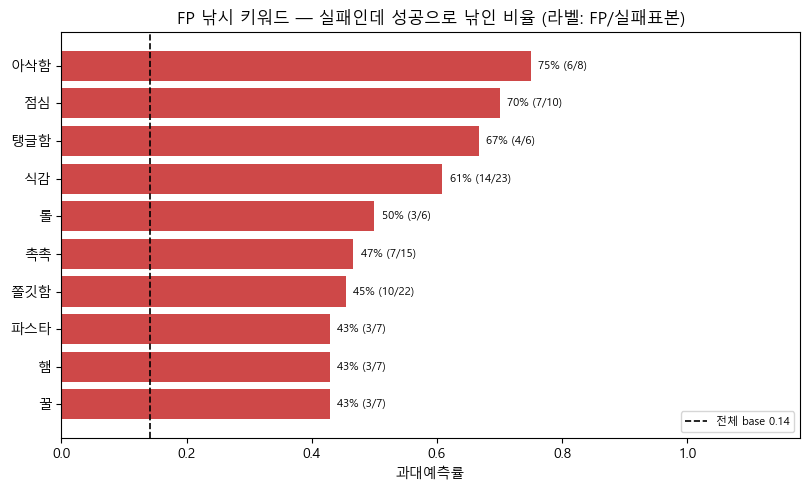

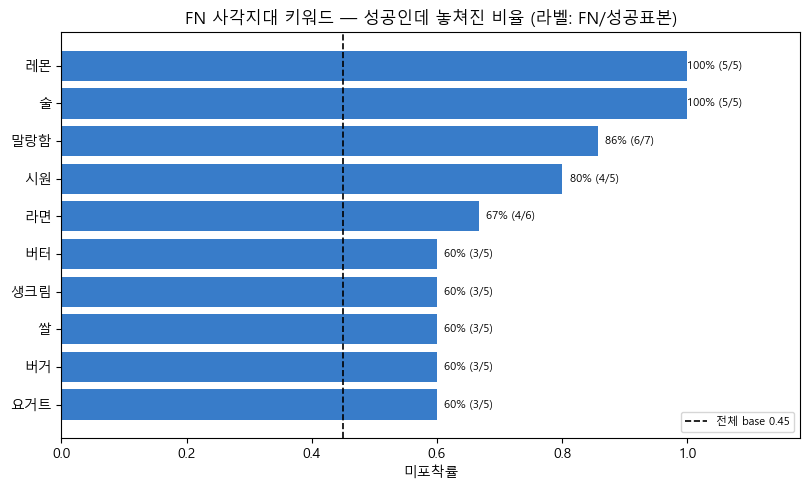

In [2]:
# [2] 키워드 그림 — FP 낚시 / FN 사각지대
def barh(tbl,ratecol,cntcol,suppcol,base,title,fname,color):
    d=tbl.head(10).iloc[::-1]
    fig,ax=plt.subplots(figsize=(8.2,5))
    ax.barh(range(len(d)),d[ratecol],color=color,alpha=.85)
    ax.axvline(base,ls='--',c='k',lw=1.2,label=f'전체 base {base:.2f}')
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index)
    for i,(r,c,s) in enumerate(zip(d[ratecol],d[cntcol],d[suppcol])): ax.text(min(r+0.012,1.0),i,f'{r:.0%} ({int(c)}/{int(s)})',va='center',fontsize=8)
    ax.set_xlim(0,1.18); ax.set_xlabel(ratecol); ax.set_title(title); ax.legend(loc='lower right',fontsize=8)
    plt.tight_layout(); savefig(fig,fname); plt.show()
barh(fp_kw,'과대예측률','FP','실패표본',baseFP,'FP 낚시 키워드 — 실패인데 성공으로 낚인 비율 (라벨: FP/실패표본)','mis_fp_kw.png','#c62828')
barh(fn_kw,'미포착률','FN','성공표본',baseFN,'FN 사각지대 키워드 — 성공인데 놓쳐진 비율 (라벨: FN/성공표본)','mis_fn_kw.png','#1565c0')

FP IP 표본 부족(자격 2개) → 그림 생략


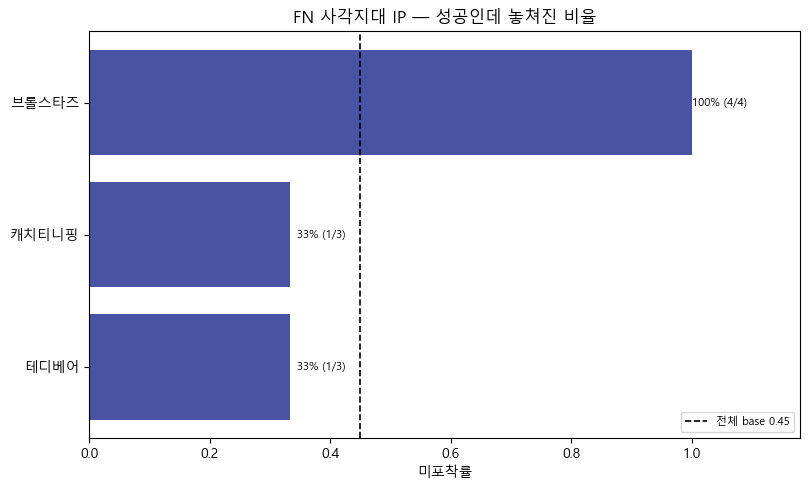

In [3]:
# [3] IP 그림 (표본 충분할 때만; 아니면 표만)
if len(fp_ip)>=3: barh(fp_ip,'과대예측률','FP','실패표본',baseFP,'FP 낚시 IP — 실패인데 성공으로 낚인 비율','mis_fp_ip.png','#ad1457')
else: print('FP IP 표본 부족(자격 %d개) → 그림 생략'%len(fp_ip))
if len(fn_ip)>=3: barh(fn_ip,'미포착률','FN','성공표본',baseFN,'FN 사각지대 IP — 성공인데 놓쳐진 비율','mis_fn_ip.png','#283593')
else: print('FN IP 표본 부족(자격 %d개) → 그림 생략'%len(fn_ip))

In [4]:
# [4] 보고서 md 생성
def tbl_md(df,cols,headers):
    out=['| '+' | '.join(headers)+' |','|'+'|'.join(['---']*len(headers))+'|']
    for k,r in df.iterrows():
        def _fmt(cc,v):
            if cc in ('과대예측률','미포착률'): return f'{v:.0%}'
            if cc=='lift': return f'{v:.2f}'
            if cc in ('FP','FN','실패표본','성공표본'): return str(int(v))
            return str(v)
        cells=[str(k)]+[_fmt(c,r[c]) for c in cols]
        out.append('| '+' | '.join(cells)+' |')
    return '\n'.join(out)
L=[]; A=L.append
A('# 오분류 다발 키워드·IP 분석 — 무엇이 모델을 헷갈리게 하나\n')
A(f'> v2_sweepA · test 754개 · **배포 운영점 THR={THR:.4f}** · 분면 TP{int(vc["TP"])}/FP{int(vc["FP"])}/FN{int(vc["FN"])}/TN{int(vc["TN"])} · `misclassification_keywords.ipynb` Run All 자동 생성.\n')
A('## 0. 소목적 · 지표\n')
A('FP(낚인 실패)·FN(놓친 성공)에 유난히 얽힌 **키워드·IP**를 찾아, 모델의 오분류를 *구체적 콘텐츠*로 설명한다(상위목적과 연결).\n')
A('※ 분석 임계값 = **실제 배포 운영점 THR=0.7049**(serve.py 계열). 분석용 val F1-max(0.56)보다 보수적이라 FP는 줄고 FN은 늘며 base율도 달라진다(과대예측률 base↓·미포착률 base↑).\n')
A(f'- **과대예측률(FP)** = FP/(FP+TN) = 그 키워드를 가진 **실제 실패** 제품이 성공으로 낚인 비율 (전체 base **{baseFP:.0%}**).')
A(f'- **미포착률(FN)** = FN/(FN+TP) = 그 키워드를 가진 **실제 성공** 제품이 실패로 놓쳐진 비율 (전체 base **{baseFN:.0%}**).')
A('- 단순 빈도(간식·달콤 등 흔한 키워드)는 제외. 표본 필터 FP: 실패표본≥5·FP≥3 / FN: 성공표본≥5·FN≥2. lift = 율/base.\n')
A('## 1. FP 낚시 키워드 — 실패인데 성공으로 낚이게 만드는 키워드\n')
A('![FP 낚시 키워드](report_assets/mis_fp_kw.png)\n')
A(tbl_md(fp_kw.head(12),['과대예측률','FP','실패표본','lift','태그'],['키워드','과대예측률','FP','실패표본','lift','성격태그'])+'\n')
A(f'**📌** 이 키워드들을 가진 실패 제품은 평균(base {baseFP:.0%})보다 훨씬 자주 성공으로 과대예측된다. 트렌드/유사 성공작 외형 키워드가 모델을 낚는다(M1·M2의 FP 트렌드 최고와 정합).\n')
A('## 2. FN 사각지대 키워드 — 성공인데 놓치게 만드는 키워드\n')
A('![FN 사각지대 키워드](report_assets/mis_fn_kw.png)\n')
A(tbl_md(fn_kw.head(12),['미포착률','FN','성공표본','lift','태그'],['키워드','미포착률','FN','성공표본','lift','성격태그'])+'\n')
A(f'**📌** 이 키워드들을 가진 성공 제품은 평균(base {baseFN:.0%})보다 자주 놓쳐진다. 유사 성공작이 없는 희귀·신규 성격 키워드가 사각지대(keyword_generality의 "고성공=희귀"와 정합).\n')
A('## 3. IP\n')
if len(fp_ip)>=3:
    A('**FP 낚시 IP**\n'); A('![FP 낚시 IP](report_assets/mis_fp_ip.png)\n'); A(tbl_md(fp_ip.head(10),['과대예측률','FP','실패표본','lift'],['IP','과대예측률','FP','실패표본','lift'])+'\n')
else: A(f'- FP 낚시 IP: 자격 표본 {len(fp_ip)}개로 부족(IP는 제품당 0~소수라 희소) → 생략.\n')
if len(fn_ip)>=3:
    A('**FN 사각지대 IP**\n'); A('![FN 사각지대 IP](report_assets/mis_fn_ip.png)\n'); A(tbl_md(fn_ip.head(10),['미포착률','FN','성공표본','lift'],['IP','미포착률','FN','성공표본','lift'])+'\n')
else: A(f'- FN 사각지대 IP: 자격 표본 {len(fn_ip)}개로 부족 → 생략.\n')
A('## 종합 · 한계\n')
A('- **FP**: 트렌드·유사 성공작 외형 키워드가 실패작을 성공으로 낚는다. **FN**: 희귀·신규(특이 성공 신호 없는) 키워드가 성공작을 사각지대로 만든다. → M1·M2·M3·keyword_generality와 같은 결론을 *실제 키워드 이름*으로 확인.\n')
A(f'- **한계**: test 소표본(FP{int(vc["FP"])}·FN{int(vc["FN"])})이라 키워드별 표본도 작음(상위도 표본 5~수십) → 방향·예시로만 해석. **상관이지 인과 아님**(이 키워드가 오분류를 *유발*한다는 증거 아님).\n')
open(NBDIR/'misclassification_keywords_report.md','w',encoding='utf-8').write('\n'.join(L))
print('생성: misclassification_keywords_report.md')

생성: misclassification_keywords_report.md
